In [1]:
import numpy as np
import pandas as pd
from rapidfuzz.distance import Levenshtein
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform


import Bio 
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import AlignIO
import logomaker

In [2]:
import tempfile
from pathlib import Path
import subprocess
from io import StringIO

def malign(seqs, tmp_dir:Path|None=None):
    seqs = [SeqRecord(s) for s in seqs]

    if tmp_dir is None:
        tmpdir_ = tempfile.TemporaryDirectory()
        tmp_dir = Path(tmpdir_.name)
    # write to fasta
    (tmp_dir/'input_mafft.fa').unlink(missing_ok=True)
    with open(tmp_dir/'input_mafft.fa', 'a') as handle:
        for i in seqs:
            SeqIO.write(i, handle ,'fasta')
    # align using mafft
    out_path = tmp_dir/"mafft_out.fa"
    cmd = ['mafft', '--auto', '--inputorder', f'{tmp_dir/"input_mafft.fa"}']
    
    try:
        with open(out_path, "w") as out_f:
            result = subprocess.run(cmd, stdout=out_f, stderr=subprocess.PIPE,
                text=True, check=True)

        with open(out_path, "r") as rf:
            align = AlignIO.read(rf, "fasta")
        #tmpdir_.cleanup()
        return align
    except subprocess.CalledProcessError as e:
        print(f"Failed with code {e.returncode}")
        raise e

def get_logo(seqs, **kwargs):
    align = malign(seqs, tmp_dir=Path("."))
    return logomaker.Logo(pd.DataFrame(align.alignment.frequencies), **kwargs)

import matplotlib.pyplot as plt

In [3]:
#CLustering

AA = list("ACDEFGHIKLMNPQRSTVWY")

# Pairwise distance matrix
def distance_matrix(seqs):
    n = len(seqs)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            # normalized edit distance -> length-robust
            d = Levenshtein.normalized_distance(seqs[i], seqs[j])
            D[i, j] = D[j, i] = d
    return D

# Cluster 
def cluster_seqs(seqs, threshold=0.3):
    D = distance_matrix(seqs)
    Z = linkage(squareform(D, checks=False), method="average")
    dendrogram(Z)
    labels = fcluster(Z, t=threshold, criterion="distance")
    return labels

In [4]:
df = pd.read_csv("./figures/full_run_data.csv", index_col=0)

cluster_a     1
cluster_b     1
cluster_ab    1
dtype: int64


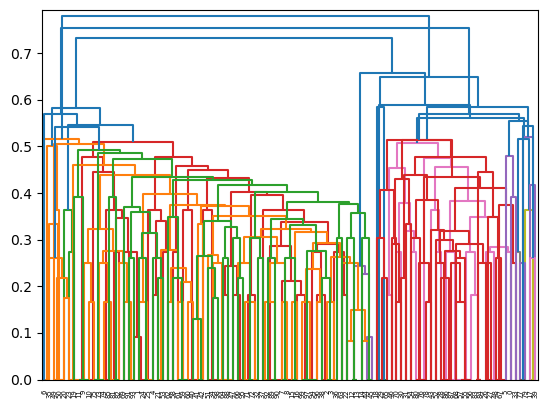

In [5]:
df[["cluster_a", "cluster_b", "cluster_ab"]] = pd.NA
df.loc[df["in_pool"],"cluster_a"] = cluster_seqs(df.loc[df["in_pool"],"acdr3"].values, threshold=0.8)
df.loc[df["in_pool"],"cluster_b"] = cluster_seqs(df.loc[df["in_pool"],"bcdr3"].values, threshold=0.8)
df.loc[df["in_pool"],"cluster_ab"] = cluster_seqs(df.loc[df["in_pool"]][["acdr3", "bcdr3"]].apply(lambda x: "".join(x.to_list()), axis=1).values, threshold=0.8)
print(df.loc[df["in_pool"], ["cluster_a", "cluster_b", "cluster_ab"]].nunique())

/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(
/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


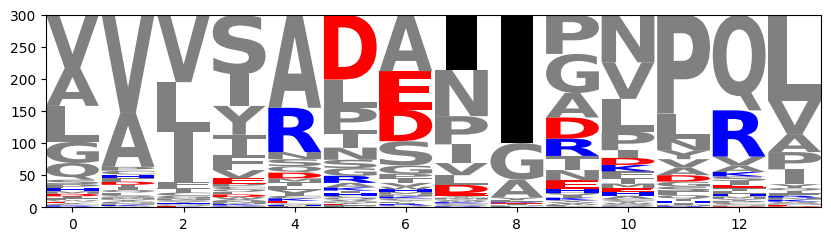

In [12]:
get_logo(df.loc[df["in_pool"], "acdr3"], color_scheme="charge")

In [ ]:
col = "cluster_ab"
s = ["acdr3","bcdr3"]
df.loc[df["in_pool"],col] = cluster_seqs(df.loc[df["in_pool"],s].values, threshold=0.75)

clusters = np.unique(df.loc[df["in_pool"],col].dropna())
fig, axes = plt.subplots(nrows=len(clusters), figsize=(10,len(clusters)*5))
for c, ax in zip(clusters, axes):
    get_logo(df.loc[df[col]==c, s], color_scheme="hydrophobicity", ax=ax)
    ax.set_xlabel(f"cluster: {c} with {sum(df[col]==c)} members with mean score {df.loc[df[col]==c, 'score'].mean()}")

/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(
/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))
/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(
/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'B' is not in color_dict. Using black.
  warnings.warn(str(Error))
/p/p

<Axes: xlabel='cluster_a', ylabel='score'>

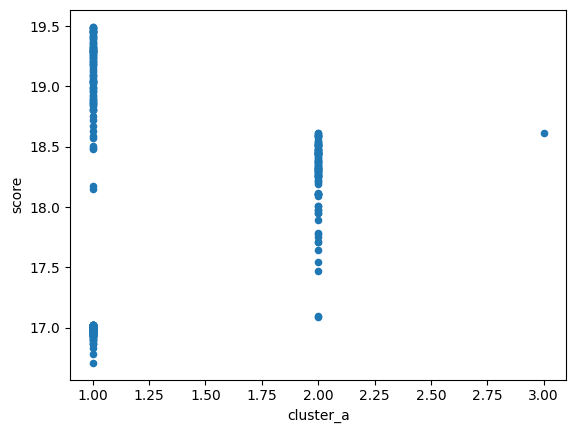

In [ ]:
df.loc[df["in_pool"]].plot("cluster_a", "score", kind="scatter")

In [142]:
np.unique(df.loc[df["in_pool"], col].dropna(), return_counts=True)

(array([1, 2, 3], dtype=object), array([200,  99,   1]))

[1 2 3]
1 200
                                       config  \
418    boltz:True\nmsa:False\ntemplates:False   
557    boltz:True\nmsa:False\ntemplates:False   
672    boltz:True\nmsa:False\ntemplates:False   
759    boltz:True\nmsa:False\ntemplates:False   
780    boltz:True\nmsa:False\ntemplates:False   
...                                       ...   
11921  boltz:False\nmsa:True\ntemplates:False   
11958  boltz:False\nmsa:True\ntemplates:False   
11981  boltz:False\nmsa:True\ntemplates:False   
11992  boltz:False\nmsa:True\ntemplates:False   
12207  boltz:False\nmsa:True\ntemplates:False   

                                                  design      score  \
418    7N2R+MAVMAPRTLV+TLMSAMTNL+CALSDSSYKL+CASSRDNSG...  19.288246   
557    7N2R+MAVMAPRTLV+TLMSAMTNL+CAAADSNYQL+CASAASGAD...  18.841257   
672    7N2R+MAVMAPRTLV+TLMSAMTNL+CAAADSNYQL+CASAASGAD...  19.484514   
759    7N2R+MAVMAPRTLV+TLMSAMTNL+CAVRDYGNNR+CASRSGTNN...  19.242731   
780    7N2R+MAVMAPRTLV+TLMSAMTNL+CAVRDYGNN

/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(
/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


2 99
                                      config  \
13212  boltz:False\nmsa:True\ntemplates:True   
13317  boltz:False\nmsa:True\ntemplates:True   
13363  boltz:False\nmsa:True\ntemplates:True   
13412  boltz:False\nmsa:True\ntemplates:True   
13428  boltz:False\nmsa:True\ntemplates:True   
...                                      ...   
14604  boltz:False\nmsa:True\ntemplates:True   
14608  boltz:False\nmsa:True\ntemplates:True   
14610  boltz:False\nmsa:True\ntemplates:True   
14626  boltz:False\nmsa:True\ntemplates:True   
14630  boltz:False\nmsa:True\ntemplates:True   

                                                  design      score  \
13212  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  18.380999   
13317  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  18.363846   
13363  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  18.611073   
13412  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  18.347696   
13428  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  17.97

/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(


3 1
                                      config  \
14493  boltz:False\nmsa:True\ntemplates:True   

                                                  design      score  \
14493  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTN...  18.614622   

                                                scaffold         time  \
14493  3GSN+MAVMAPRTLV+TLMSAMTNL+CAVSDLSGGF+CASSQKTTNE_0  1345.466667   

       in_pool tcr_chain_index mhc_chain_index  mhc_class  acdr1  ... cdr_len  \
14493     True          (0, 1)            (3,)          1  SSNFY  ...      28   

        gly_ala receptor         mhc    antigen       cdr3a       cdr3b  \
14493  0.214286     3GSN  MAVMAPRTLV  TLMSAMTNL  CAVSDLSGGF  CASSQKTTNE   

      cluster_a cluster_b cluster_ab  
14493         3         1          1  

[1 rows x 32 columns]


/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/Bio/SeqRecord.py:228: BiopythonDeprecationWarning: Using a string as the sequence is deprecated and will raise a TypeError in future. It has been converted to a Seq object.
  warnings.warn(


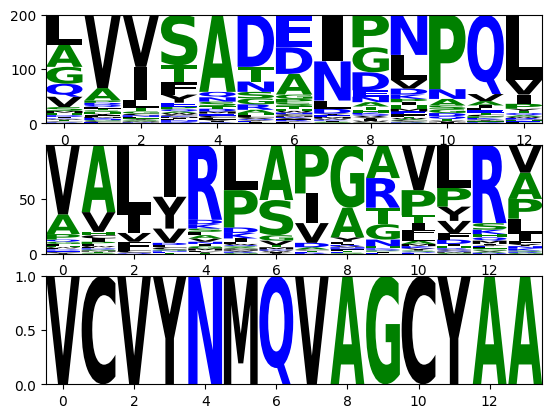

In [144]:

col = "cluster_a"
clusters = np.unique(df.loc[df["in_pool"],col].dropna())
print(clusters)
fig, axes = plt.subplots(nrows=len(clusters))
for c, ax in zip(clusters, axes):
    print(c, len(df.loc[df[col]==c]))
    print(df.loc[df[col]==c])
    get_logo(df.loc[df[col]==c, "acdr3"], color_scheme="hydrophobicity", ax=ax)

In [ ]:
import logomaker
ppm = results[list(results)[0]]["ppm"]
info = logomaker.transform_matrix(ppm.T, from_type="probability", to_type="information")
logomaker.Logo(info)

/p/project1/hai_1252/toulouse1/miniforge3/envs/flexcraft/lib/python3.10/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character '-' is not in color_dict. Using black.
  warnings.warn(str(Error))


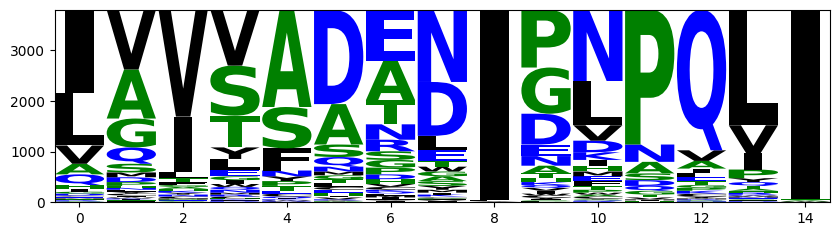

In [104]:
import logomaker
#hydrophobicity’, ‘chemistry’, or ‘charge
logomaker.Logo(pd.DataFrame(a.alignment.frequencies), color_scheme="hydrophobicity")

In [80]:
df.loc[df["cluster_a"]==1 & df["in_pool"], "acdr3"]

418       QVRADGLESDQF
557       AVVSACALLAQL
672       ALVPADSPVSQL
759      AVLLADPLALPQL
780      AVNSNDPLALPQL
             ...      
11921    AAVYADANYHPQI
11958    LDITADENDFPQL
11981    HYVYADANNNPQI
11992    IGISADENGNPQL
12207    LAVTADELTNPQL
Name: acdr3, Length: 200, dtype: object